<a href="https://colab.research.google.com/github/leshaz44/Aliaksei/blob/main/Task_6/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 0.0026
Epoch 2/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 6.2429e-04
Epoch 3/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 5.3860e-04
Epoch 4/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 5.1686e-04
Epoch 5/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 4.7906e-04
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Метрики качества модели:
Обучающая выборка:
  RMSE: 50.79
  MAE: 41.77
  R2: 0.9877

Тестовая выборка:
  RMSE: 133.13
  MAE: 115.54
  R2: 0.8582


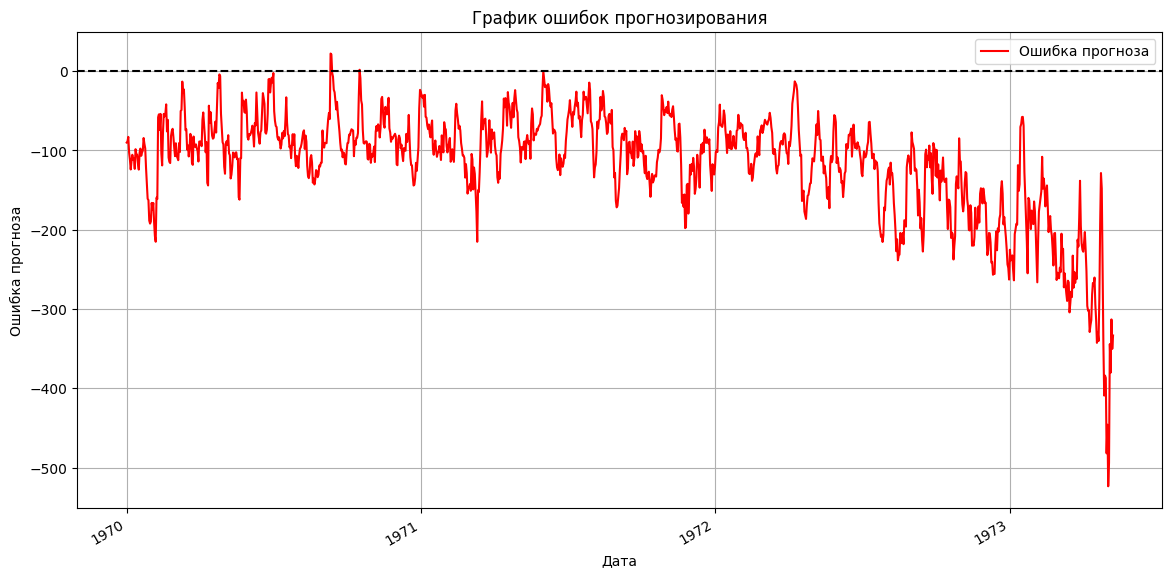

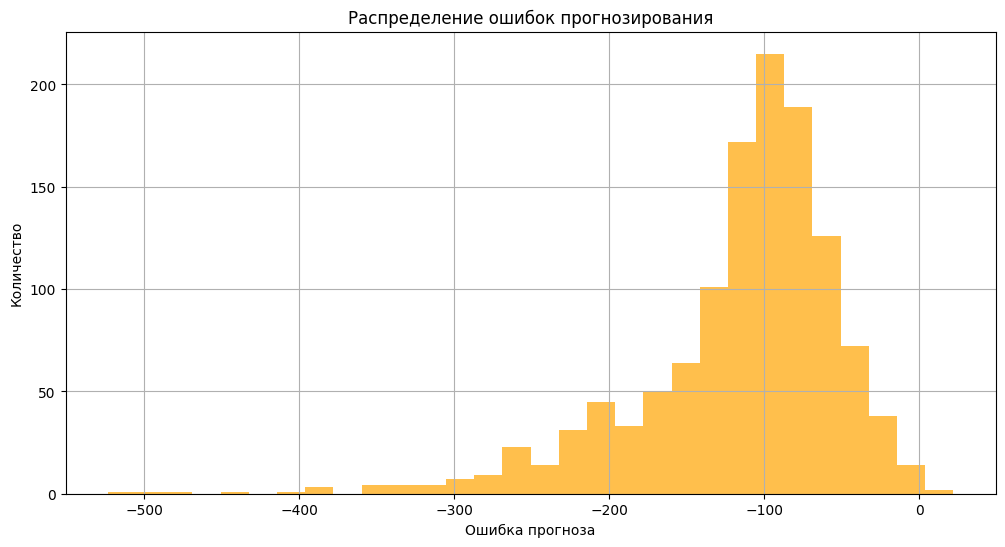

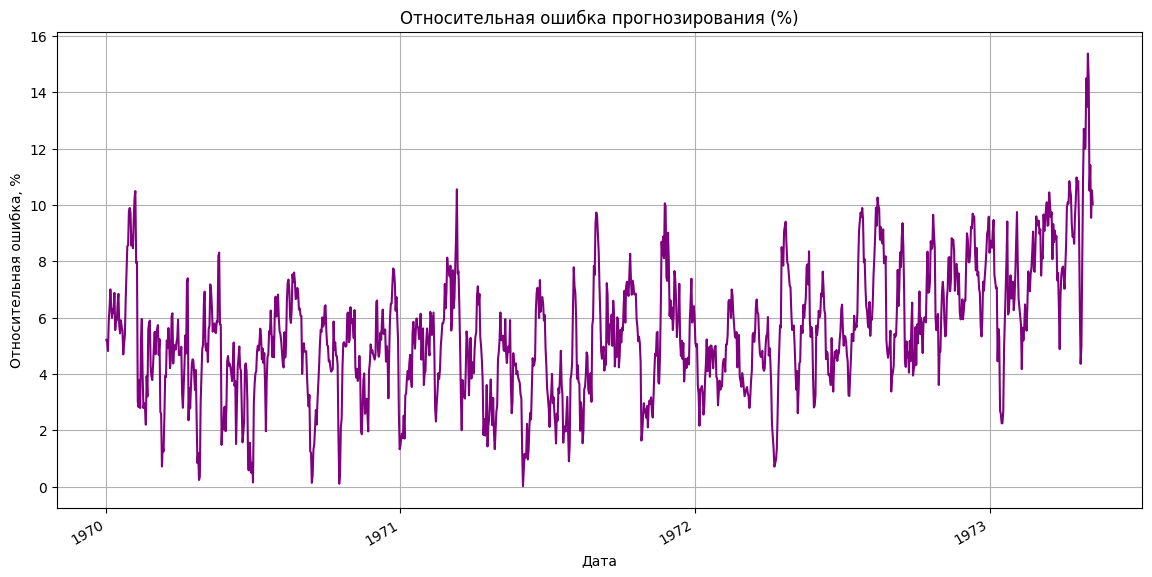


MAPE на тестовой выборке: 5.43%


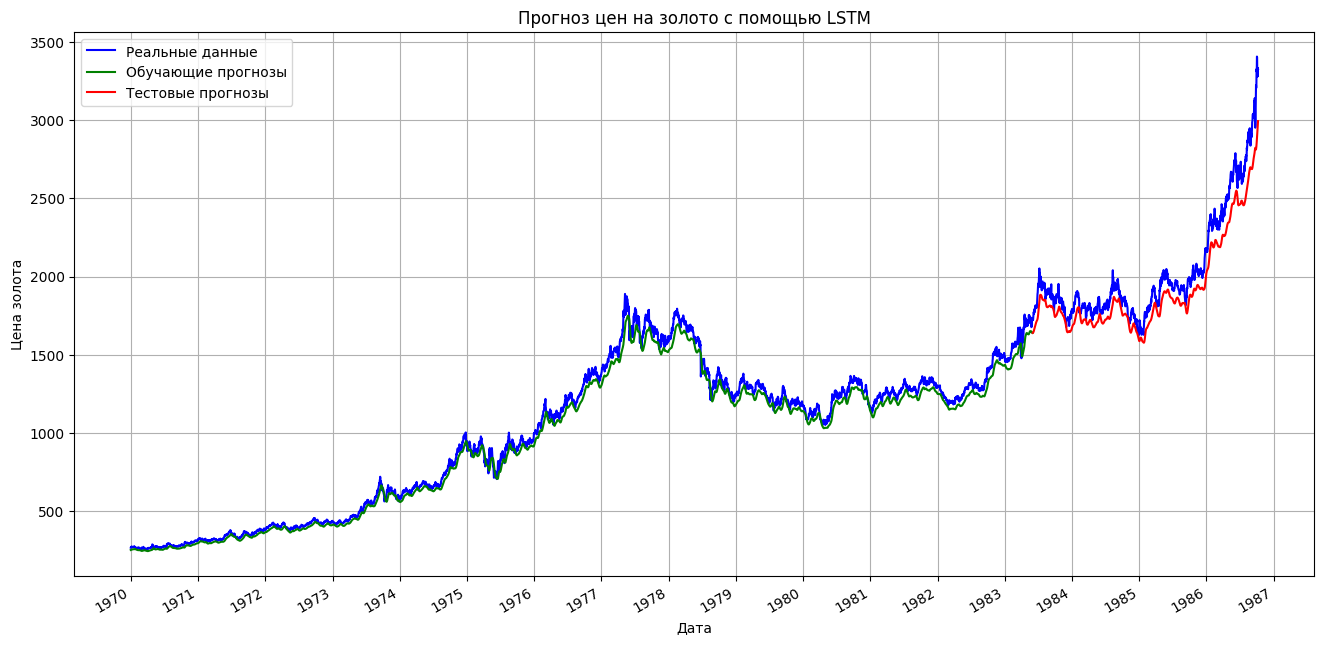

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.dates as mdates
from tensorflow.keras.models import Model

# Загрузка данных
df = pd.read_csv('Futures_Resources_Data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Выбираем только данные по золоту
gold_data = df['GC=F_closing_price'].dropna()

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(gold_data.values.reshape(-1,1))

# Создание обучающих последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:(i+seq_length)])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Корректное построение модели с использованием Input слоя
input_layer = Input(batch_shape=(None, X_train.shape[1], 1))
lstm_1 = LSTM(units=50, return_sequences=True)(input_layer)
dropout_1 = Dropout(0.2)(lstm_1)
lstm_2 = LSTM(units=50, return_sequences=False)(dropout_1)
dropout_2 = Dropout(0.2)(lstm_2)
output_layer = Dense(units=1)(dropout_2)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(optimizer='adam', loss='mean_squared_error')

# Обучение модели
model.fit(X_train, y_train, epochs=5, batch_size=32)

# Прогнозирование
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Обратное преобразование масштабирования
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_true = scaler.inverse_transform(y.reshape(-1,1))

# Метрики качества
train_rmse = np.sqrt(mean_squared_error(y_true[:len(train_predict)], train_predict))
test_rmse = np.sqrt(mean_squared_error(y_true[-len(test_predict):], test_predict))
train_mae = mean_absolute_error(y_true[:len(train_predict)], train_predict)
test_mae = mean_absolute_error(y_true[-len(test_predict):], test_predict)
train_r2 = r2_score(y_true[:len(train_predict)], train_predict)
test_r2 = r2_score(y_true[-len(test_predict):], test_predict)

print("\nМетрики качества модели:")
print(f"Обучающая выборка:")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  MAE: {train_mae:.2f}")
print(f"  R2: {train_r2:.4f}")

print(f"\nТестовая выборка:")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  MAE: {test_mae:.2f}")
print(f"  R2: {test_r2:.4f}")

# График ошибок прогнозирования
plt.figure(figsize=(14, 7))
plt.plot(gold_data.index[-len(test_predict):],
         (test_predict - y_true[-len(test_predict):]).flatten(),
         label='Ошибка прогноза', color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('График ошибок прогнозирования')
plt.xlabel('Дата')
plt.ylabel('Ошибка прогноза')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

# Гистограмма распределения ошибок
plt.figure(figsize=(12, 6))
plt.hist((test_predict - y_true[-len(test_predict):]).flatten(),
         bins=30, color='orange', alpha=0.7)
plt.title('Распределение ошибок прогнозирования')
plt.xlabel('Ошибка прогноза')
plt.ylabel('Количество')
plt.grid(True)
plt.show()

# График относительной ошибки
plt.figure(figsize=(14, 7))
relative_error = np.abs((test_predict - y_true[-len(test_predict):]) / y_true[-len(test_predict):]) * 100
plt.plot(gold_data.index[-len(test_predict):], relative_error, color='purple')
plt.title('Относительная ошибка прогнозирования (%)')
plt.xlabel('Дата')
plt.ylabel('Относительная ошибка, %')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

# Дополнительные метрики
from sklearn.metrics import mean_absolute_percentage_error

# MAPE для тестовой выборки
test_mape = mean_absolute_percentage_error(y_true[-len(test_predict):], test_predict) * 100
print(f"\nMAPE на тестовой выборке: {test_mape:.2f}%")

# Визуализация результатов
plt.figure(figsize=(16, 8))
plt.plot(gold_data.index[sequence_length:], y_true, label='Реальные данные', color='blue')
plt.plot(gold_data.index[sequence_length:len(train_predict)+sequence_length],
         train_predict, label='Обучающие прогнозы', color='green')
plt.plot(gold_data.index[-len(test_predict):],
         test_predict, label='Тестовые прогнозы', color='red')
plt.title('Прогноз цен на золото с помощью LSTM')
plt.xlabel('Дата')
plt.ylabel('Цена золота')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()